In [48]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = r"\Users\W67437\Downloads\Projects\potato_disease\PlantVillage"

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(path,
                                                   shuffle = True,
                                                   image_size = (IMAGE_SIZE,IMAGE_SIZE),
                                                   batch_size = BATCH_SIZE)

Found 2152 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

68

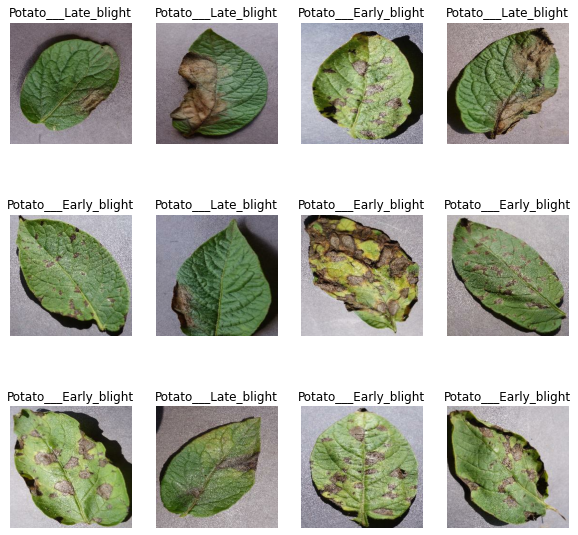

In [7]:
plt.figure(figsize = (10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
#     print(image_batch.shape)
#     print(label_batch.numpy())
#     print(image_batch[0].shape)
        ax = plt.subplot(3,4,i+1)
        plt.title(class_names[label_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [8]:
len(dataset)

68

In [9]:
# Split the dataset into training and testing
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [10]:
train_ds = dataset.take(54)
len(train_ds)

54

In [11]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [12]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [13]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [14]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [15]:
def get_dataset_partitions_tf(
    ds, train_split = 0.8, val_split = 0.1, test_split = 0.1,
    shuffle = True, shuffle_size = 10000
):
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    ds_size = len(dataset)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds


In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [17]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


In [18]:
#caching = This will read the img from the disk and for the 
#next iteration if you need that image it will keep it in the memory this 
#improves the performance of your pipeline

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [19]:
# Pre-processing
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(IMAGE_SIZE,IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [20]:
# pre-processing layers
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    
])

In [27]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation = 'relu',
                input_shape = input_shape),
                layers.MaxPooling2D((2,2)),
                layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
                layers.MaxPooling2D((2,2)),
                layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
                layers.MaxPooling2D((2,2)),
                layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
                layers.MaxPooling2D((2,2)),
                layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
                layers.MaxPooling2D((2,2)),
                layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
                layers.MaxPooling2D((2,2)),
                layers.Flatten(),
                layers.Dense(64, activation = 'relu'),
                layers.Dense(n_classes, activation = 'softmax'),
])
    
model.build(input_shape = input_shape)

In [28]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d_10 (Conv2D)          (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_10 (MaxPoolin  (32, 127, 127, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_11 (MaxPoolin  (32, 62, 62, 64)         0         
 g2D)                                                 

In [29]:
# we do the optimization with the help of 'adam' optimizer
# we difine the loss function and metrics is accuracy to track the training process
model.compile(
optimizer = 'adam',
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
metrics = ['accuracy'])

In [30]:
history = model.fit(
train_ds,
epochs = EPOCHS,
batch_size = BATCH_SIZE,
verbose = 1,
validation_data = val_ds
)

Epoch 1/50
54/54 [==============================] - 103s 2s/step - loss: 1.6727 - accuracy: 0.5590 - val_loss: 0.8196 - val_accuracy: 0.5365
Epoch 2/50
54/54 [==============================] - 87s 2s/step - loss: 0.4750 - accuracy: 0.7905 - val_loss: 0.3858 - val_accuracy: 0.8542
Epoch 3/50
54/54 [==============================] - 90s 2s/step - loss: 0.3055 - accuracy: 0.8721 - val_loss: 0.3213 - val_accuracy: 0.9115
Epoch 4/50
54/54 [==============================] - 91s 2s/step - loss: 0.2424 - accuracy: 0.9028 - val_loss: 0.1552 - val_accuracy: 0.9271
Epoch 5/50
54/54 [==============================] - 93s 2s/step - loss: 0.2171 - accuracy: 0.9184 - val_loss: 0.1990 - val_accuracy: 0.9115
Epoch 6/50
54/54 [==============================] - 90s 2s/step - loss: 0.1879 - accuracy: 0.9300 - val_loss: 0.1301 - val_accuracy: 0.9427
Epoch 7/50
54/54 [==============================] - 96s 2s/step - loss: 0.1463 - accuracy: 0.9421 - val_loss: 0.1067 - val_accuracy: 0.9635
Epoch 8/50
54/54 [=

In [31]:
scores = model.evaluate(test_ds)

8/8 [==============================] - 5s 354ms/step - loss: 0.1484 - accuracy: 0.9531


In [32]:
scores

[0.14836828410625458, 0.953125]

In [34]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [35]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [38]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [39]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Training and Validation Accuracy')

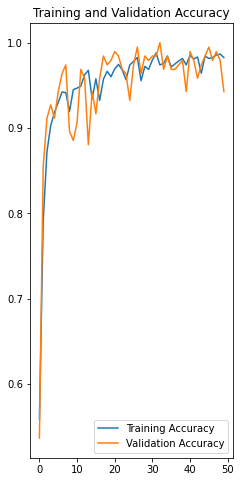

In [40]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label = 'Training Accuracy')
plt.plot(range(EPOCHS), val_acc,label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

first image to predict
first image's: Potato___Early_blight
1/1 [==============================] - 0s 408ms/step
predicted_label: Potato___Early_blight


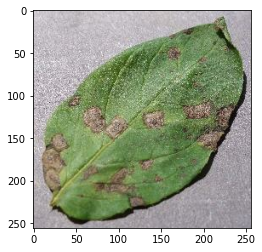

In [54]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = (images_batch[0].numpy().astype('uint8'))
    first_label = labels_batch[0]
    
    print('first image to predict')
    plt.imshow(first_image)
    print("first image's:" ,class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print('predicted_label:', class_names[np.argmax(batch_prediction[0])])

In [51]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # create a batch
    
    predictions = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 68ms/step


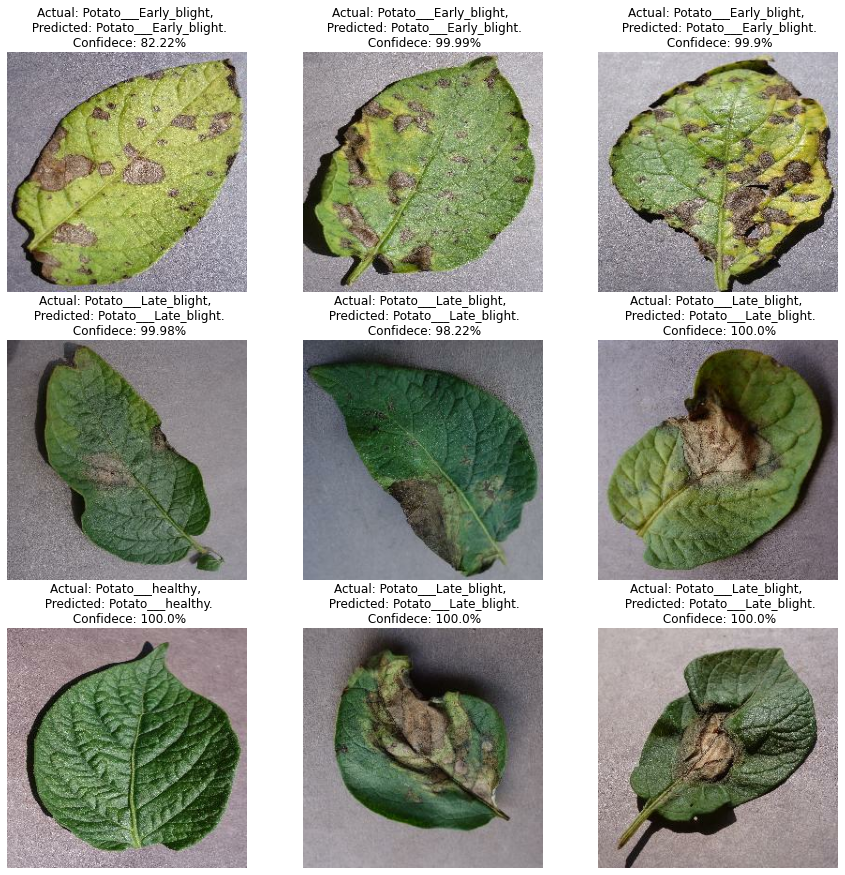

In [58]:
plt.figure(figsize = (15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.\n Confidece: {confidence}%")
        
        plt.axis("off")
        
        

In [60]:
import os

In [61]:
os.listdir("../models")

['1']

In [59]:
model_version = 1
model.save(f"../models/{model_version}")

INFO:tensorflow:Assets written to: ../models/1\assets


INFO:tensorflow:Assets written to: ../models/1\assets
